In [23]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import pandas as pd
from pathlib import Path
import importlib.util
import matplotlib.pyplot as plt

module_path = Path('../experimental_data_analysis/visualize_bandit_data.py').resolve()
spec = importlib.util.spec_from_file_location('visualize_bandit_data', module_path)
visualize_bandit_data = importlib.util.module_from_spec(spec)
spec.loader.exec_module(visualize_bandit_data)

In [25]:
data_path = '../../data/pilot_asocial/csv/mexicanHat_pilot.csv'
grid_loader_path = Path('../../soloBandit/js/gridLoader.js')
grid_dir_path = Path('../../data/pilot_asocial/reward_grids')

# Load CSV
df = pd.read_csv(data_path)

# Load bandit grids 
envs = visualize_bandit_data.load_envs(grid_loader_path, grid_dir_path, None)

## 1. Averages within envs across participants

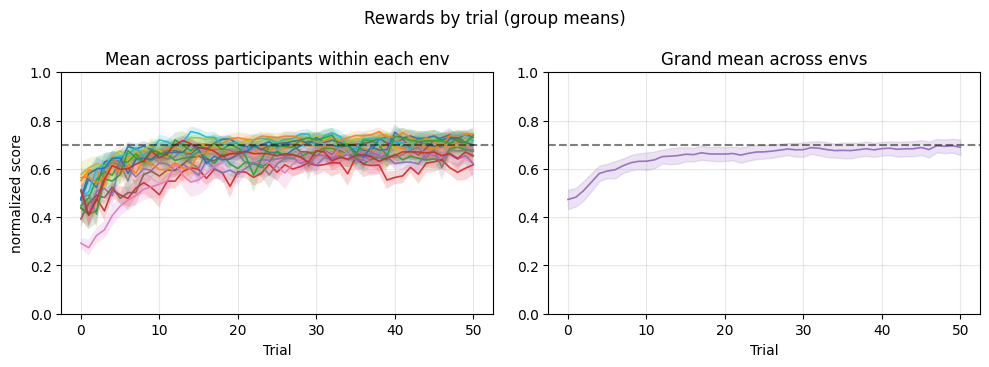

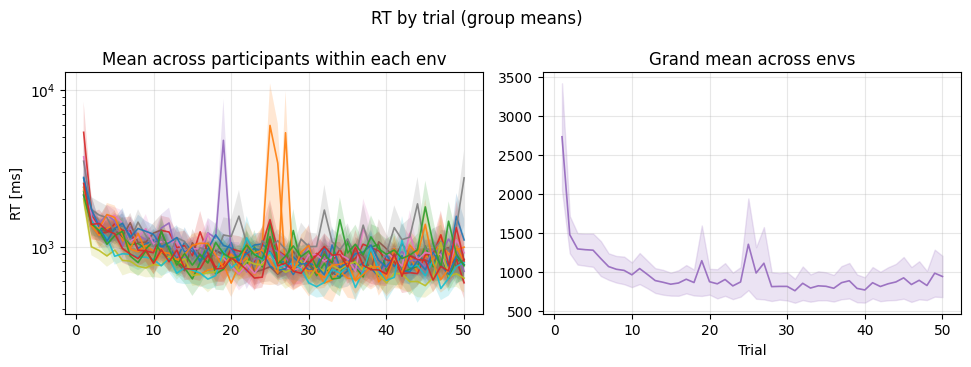

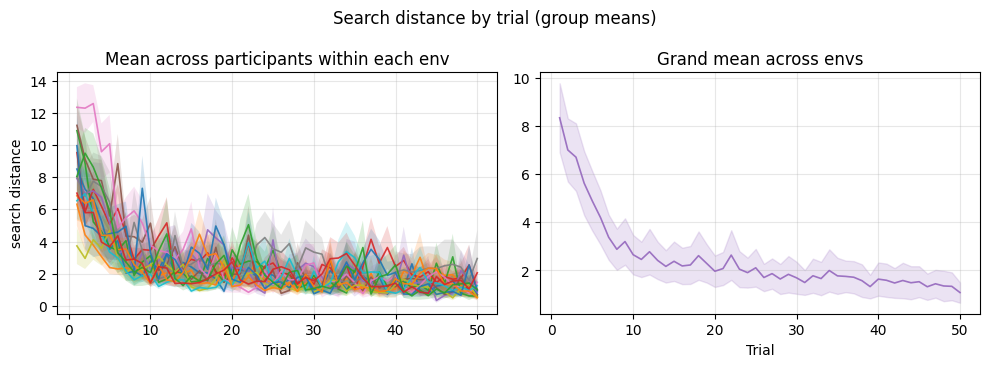

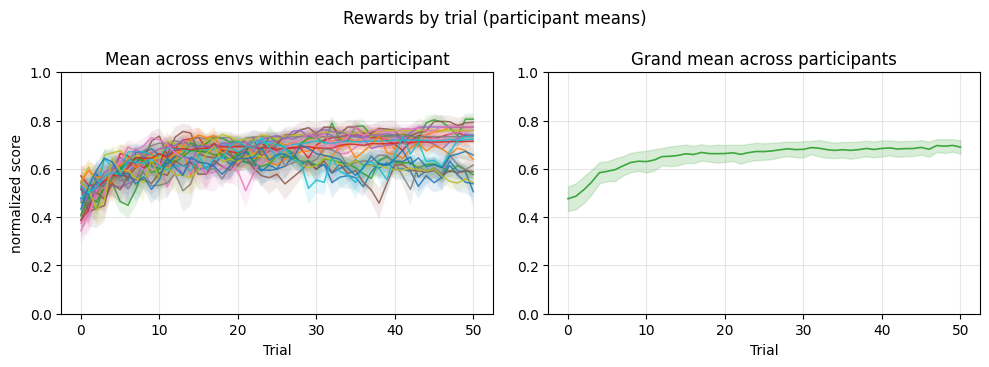

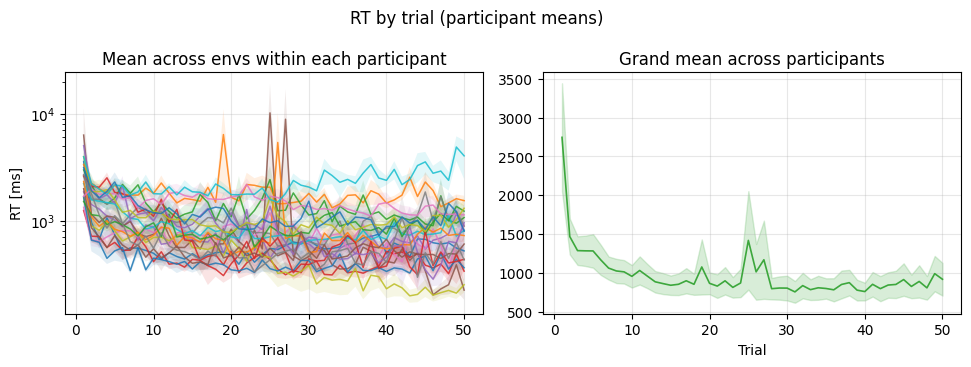

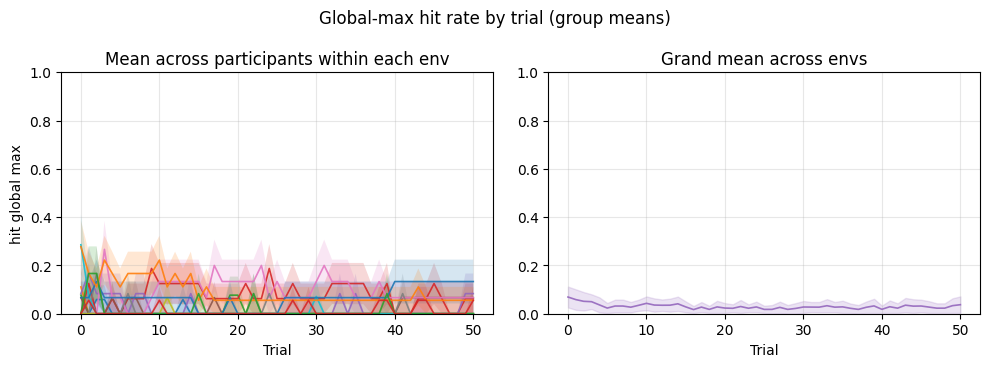

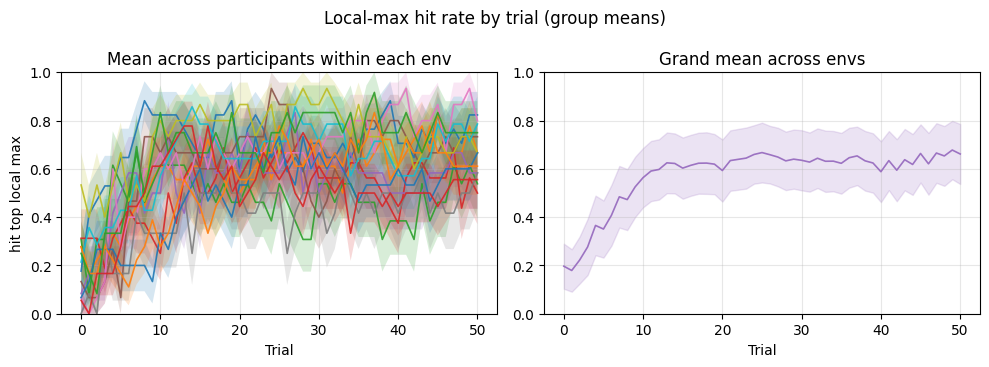

In [32]:
# prepare the dataframe for plotting.
prepared_df = visualize_bandit_data.prepare_bandit_data(
    df,
    envs=envs,
    participant_id_col='id',
    participant_id=None,
)

# grouped averages with error bars across participants, first within envs and then overall
fig_rewards, axes_rewards = visualize_bandit_data.plot_group_average_trends(
    prepared_df,
    'normalized_score',
    participant_id_col='id',
    title='Rewards by trial (group means)',
    show=False,
)
axes_rewards[0].set_ylim([0, 1])
axes_rewards[1].set_ylim([0, 1])
# plot horizontal line at 0.7
axes_rewards[0].axhline(y=0.7, color='k', linestyle='--', alpha=0.5)
axes_rewards[1].axhline(y=0.7, color='k', linestyle='--', alpha=0.5)

fig_rt, axes_rt = visualize_bandit_data.plot_group_average_trends(
    prepared_df,
    'RT',
    participant_id_col='id',
    title='RT by trial (group means)',
    show=False,
)
axes_rt[0].set_yscale('log')
axes_rt[0].set_ylabel('RT [ms]')

fig_search, axes_search = visualize_bandit_data.plot_group_average_trends(
    prepared_df,
    'search_distance',
    participant_id_col='id',
    title='Search distance by trial (group means)',
    show=False,
)

# reverse view: average across envs within each participant, then across participants
fig_rewards_participant, axes_rewards_participant = visualize_bandit_data.plot_participant_average_trends(
    prepared_df,
    'normalized_score',
    participant_id_col='id',
    title='Rewards by trial (participant means)',
    show=False,
)
axes_rewards_participant[0].set_ylim([0, 1])
axes_rewards_participant[1].set_ylim([0, 1])

fig_rt_participant, axes_rt_participant = visualize_bandit_data.plot_participant_average_trends(
    prepared_df,
    'RT',
    participant_id_col='id',
    title='RT by trial (participant means)',
    show=False,
)
axes_rt_participant[0].set_yscale('log')
axes_rt_participant[0].set_ylabel('RT [ms]')

# if maxima indicators are present, they can also be plotted this way
if 'hit_global_max' in prepared_df.columns:
    fig_hits, axes_hits = visualize_bandit_data.plot_group_average_trends(
        prepared_df,
        'hit_global_max',
        participant_id_col='id',
        title='Global-max hit rate by trial (group means)',
        show=False,
    )
    axes_hits[0].set_ylim([0, 1])
    axes_hits[1].set_ylim([0, 1])

if 'hit_top_local_max' in prepared_df.columns:
    fig_hits, axes_hits = visualize_bandit_data.plot_group_average_trends(
        prepared_df,
        'hit_top_local_max',
        participant_id_col='id',
        title='Local-max hit rate by trial (group means)',
        show=False,
    )
    axes_hits[0].set_ylim([0, 1])
    axes_hits[1].set_ylim([0, 1])


## 2. Averages within participants, across envs

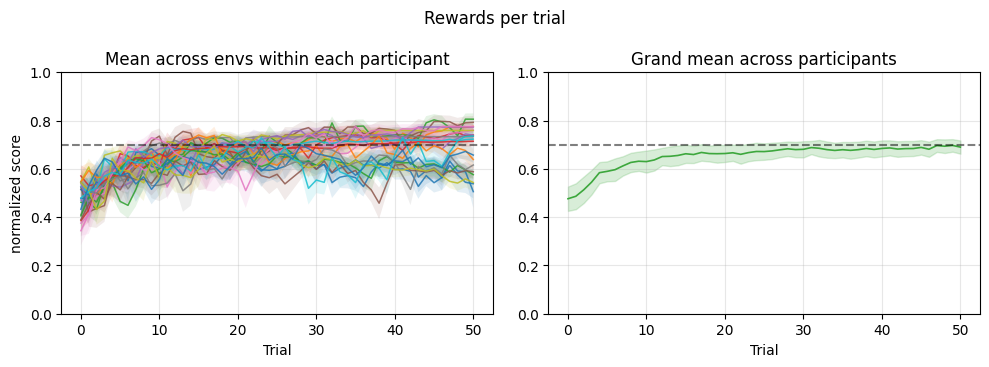

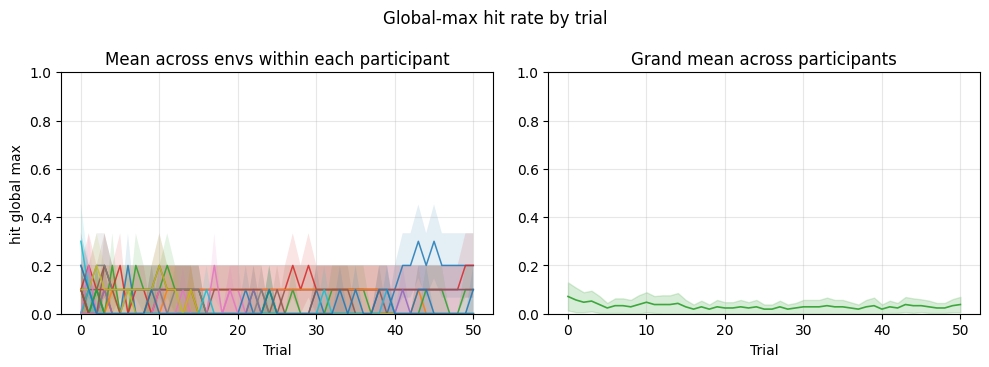

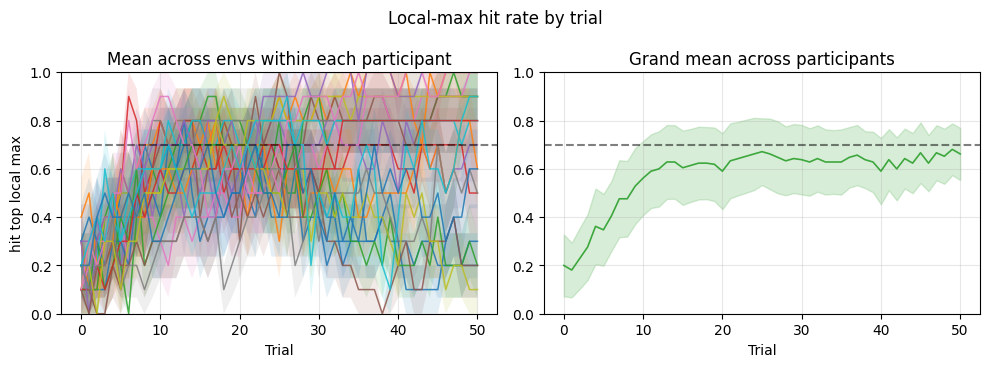

In [36]:
# grouped averages with error bars across participants, first within envs and then overall
fig_rewards, axes_rewards = visualize_bandit_data.plot_participant_average_trends(
    prepared_df,
    'normalized_score',
    participant_id_col='id',
    title='Rewards per trial',
    show=False,
)
axes_rewards[0].set_ylim([0, 1])
axes_rewards[1].set_ylim([0, 1])
# plot horizontal line at 0.7
axes_rewards[0].axhline(y=0.7, color='k', linestyle='--', alpha=0.5)
axes_rewards[1].axhline(y=0.7, color='k', linestyle='--', alpha=0.5)
plt.show()

# if maxima indicators are present, they can also be plotted this way
fig_hits, axes_hits = visualize_bandit_data.plot_participant_average_trends(
    prepared_df,
    'hit_global_max',
    participant_id_col='id',
    title='Global-max hit rate by trial',
    show=False,
)
axes_hits[0].set_ylim([0, 1])
axes_hits[1].set_ylim([0, 1])

fig_hits, axes_hits = visualize_bandit_data.plot_participant_average_trends(
    prepared_df,
    'hit_top_local_max',
    participant_id_col='id',
    title='Local-max hit rate by trial',
    show=False,
)
axes_hits[0].set_ylim([0, 1])
axes_hits[1].set_ylim([0, 1])
# plot horizontal line at 0.7
axes_hits[0].axhline(y=0.7, color='k', linestyle='--', alpha=0.5)
axes_hits[1].axhline(y=0.7, color='k', linestyle='--', alpha=0.5)